Entrenamiento completado
Video guardado como marl_video.mp4


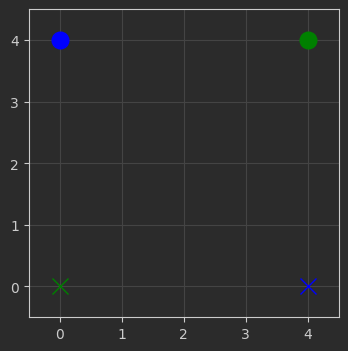

In [2]:
# Multi-agent independent Q-learning in a shared environment without interaction
#
# Interacción:    Independiente (sin cooperación ni competencia)
# Recompensas:    Individuales (cada agente recibe su propia recompensa)
# Objetivos:      Independientes (cada uno tiene su propia meta)
# Observabilidad: Totalmente observable (cada agente "ve" todo el entorno)
# Comunicación:   Ninguna
# Aprendizaje:    Independiente Q-learning
# Acciones:       Sincronizadas (ambos actúan al mismo tiempo)

# Instalar dependencias
!pip install matplotlib moviepy -q

import numpy as np
import matplotlib.pyplot as plt
import random
import matplotlib.animation as animation
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.animation import FFMpegWriter

plt.rcParams.update({
    'figure.facecolor': '#2b2b2b',     # fondo exterior
    'axes.facecolor':   '#2b2b2b',     # fondo del área del gráfico
    'axes.edgecolor':   '#cccccc',     # borde de los ejes
    'axes.labelcolor':  '#cccccc',     # etiquetas de los ejes
    'xtick.color':      '#cccccc',     # color de los números en el eje X
    'ytick.color':      '#cccccc',     # color de los números en el eje Y
    'text.color':       '#cccccc',     # color del título y textos
    'grid.color':       '#444444',     # color de la grilla
})

# Entorno
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.reset()

    def reset(self):
        self.agent_pos = [np.array([0, 0]), np.array([0, self.size - 1])]
        self.goals = [np.array([self.size - 1, self.size - 1]), np.array([self.size - 1, 0])]
        return tuple(map(tuple, self.agent_pos))

    def step(self, actions):
        rewards = []
        for i in range(2):
            move = actions[i]
            pos = self.agent_pos[i] + move
            pos = np.clip(pos, 0, self.size - 1)
            self.agent_pos[i] = pos
            rewards.append(1 if np.array_equal(pos, self.goals[i]) else -0.1)
        return tuple(map(tuple, self.agent_pos)), rewards

    def is_done(self):
        return all(np.array_equal(self.agent_pos[i], self.goals[i]) for i in range(2))

    def render(self, ax):
        ax.clear()
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(-0.5, self.size - 0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.grid(True)
        colors = ['blue', 'green']
        for i in range(2):
            ax.plot(self.agent_pos[i][1], self.size - 1 - self.agent_pos[i][0], 'o', color=colors[i], markersize=12)
            ax.plot(self.goals[i][1], self.size - 1 - self.goals[i][0], 'x', color=colors[i], markersize=12)

# Acciones
ACTIONS = [np.array([-1, 0]), np.array([1, 0]), np.array([0, -1]), np.array([0, 1])]
ACTION_IDX = range(4)

# Q-learning
def state_to_str(state):
    return str(state[0]) + '_' + str(state[1])

Q1, Q2 = {}, {}

def get_q(Q, state):
    return Q.setdefault(state_to_str(state), np.zeros(len(ACTIONS)))

def choose_action(Q, state, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTION_IDX)
    return np.argmax(get_q(Q, state))

# Entrenamiento
env = GridWorld()
episodes = 500
alpha = 0.1
gamma = 0.95
epsilon = 1.0

for ep in range(episodes):
    state = env.reset()
    for _ in range(50):
        a1 = choose_action(Q1, state, epsilon)
        a2 = choose_action(Q2, state, epsilon)
        next_state, rewards = env.step([ACTIONS[a1], ACTIONS[a2]])
        q1 = get_q(Q1, state)
        q2 = get_q(Q2, state)
        q1[a1] += alpha * (rewards[0] + gamma * np.max(get_q(Q1, next_state)) - q1[a1])
        q2[a2] += alpha * (rewards[1] + gamma * np.max(get_q(Q2, next_state)) - q2[a2])
        state = next_state
        if env.is_done():
            break
    epsilon = max(0.05, epsilon * 0.995)

print("Entrenamiento completado")

# Evaluación (grabación de video)
fig, ax = plt.subplots(figsize=(4, 4))
frames = []

state = env.reset()
trajectory = [tuple(env.agent_pos)]
for _ in range(20):
    a1 = np.argmax(get_q(Q1, state))
    a2 = np.argmax(get_q(Q2, state))
    state, _ = env.step([ACTIONS[a1], ACTIONS[a2]])
    trajectory.append(tuple(env.agent_pos))
    if env.is_done():
        break

# Función para animación
def animate(i):
    env.agent_pos = [np.array(trajectory[i][0]), np.array(trajectory[i][1])]
    env.render(ax)

ani = animation.FuncAnimation(fig, animate, frames=len(trajectory), interval=800)
ani.save("marl_video.mp4", writer=FFMpegWriter(fps=1))
print("Video guardado como marl_video.mp4")
